In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Libraries loaded!')

Libraries loaded!


In [4]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Shape: {df.shape}')
print(f'\nAttrition Distribution:')
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate yes: {df["Attrition"].value_counts(normalize=True)["Yes"]:.1%}')
print(f'\nAttrition Rate No: {df["Attrition"].value_counts(normalize=True)["No"]:.1%}')
df.head()

Shape: (1470, 35)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate yes: 16.1%

Attrition Rate No: 83.9%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

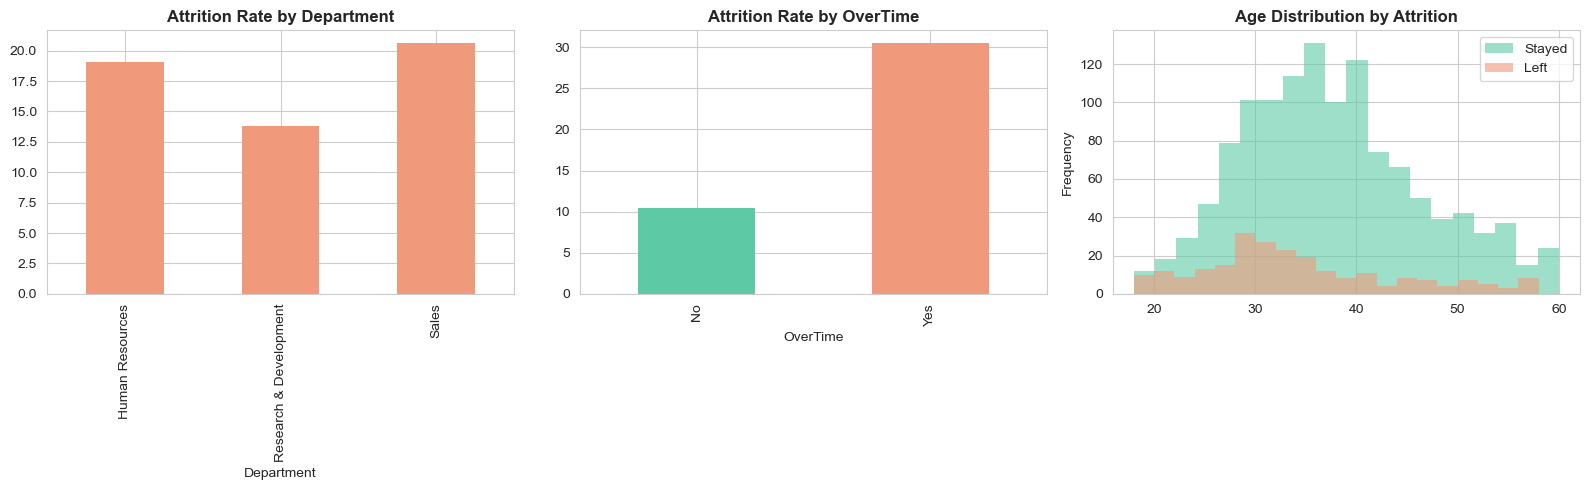

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Attrition by Department
dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean() * 100)
dept.plot(kind='bar', ax=axes[0], color='#F0997B', edgecolor='none')
axes[0].set_title('Attrition Rate by Department', fontweight='bold')

# Attrition by OverTime
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').mean() * 100)
ot.plot(kind='bar', ax=axes[1], color=['#5DCAA5','#F0997B'], edgecolor='none')
axes[1].set_title('Attrition Rate by OverTime', fontweight='bold')

# Age Distribution
df[df['Attrition']=='No']['Age'].plot(kind='hist', ax=axes[2],
    alpha=0.6, color='#5DCAA5', label='Stayed', bins=20, edgecolor='none')
df[df['Attrition']=='Yes']['Age'].plot(kind='hist', ax=axes[2],
    alpha=0.6, color='#F0997B', label='Left', bins=20, edgecolor='none')
axes[2].set_title('Age Distribution by Attrition', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('hr_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df = df.drop(['EmployeeCount', 'EmployeeNumber',
              'Over18', 'StandardHours'], axis=1)

# Encode الـ target
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode الـ categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f'Final shape: {df.shape}')
print(f'Attrition balance: {df["Attrition"].value_counts().to_dict()}')
print('\\nReady for modeling!')

Final shape: (1470, 31)
Attrition balance: {0: 1233, 1: 237}
\nReady for modeling!


In [8]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.1%}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Accuracy: 84.0%

--- Classification Report ---
              precision    recall  f1-score   support

      Stayed       0.87      0.95      0.91       247
        Left       0.50      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.69      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294



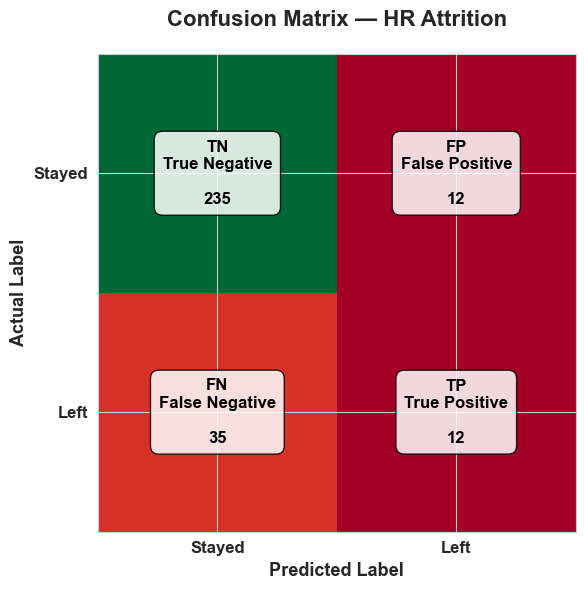

In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

# رسم الـ Confusion Matrix
im = ax.imshow(cm, cmap='RdYlGn')

# Labels للمحاور
classes = ['Stayed', 'Left']

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(classes, fontsize=12, fontweight='bold')
ax.set_yticklabels(classes, fontsize=12, fontweight='bold')

ax.set_xlabel(
    'Predicted Label',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Actual Label',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Confusion Matrix — HR Attrition',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# أسماء الخانات
labels = [
    ['TN\nTrue Negative', 'FP\nFalse Positive'],
    ['FN\nFalse Negative', 'TP\nTrue Positive']
]

# كتابة النصوص داخل المربعات
for i in range(2):
    for j in range(2):

        ax.text(
            j, i,
            f'{labels[i][j]}\n\n{cm[i, j]}',
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold',
            color='black',

            # Background للكلام
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                boxstyle='round,pad=0.5',
                alpha=0.85
            )
        )

plt.tight_layout()

plt.savefig(
    'confusion_matrix_advanced.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

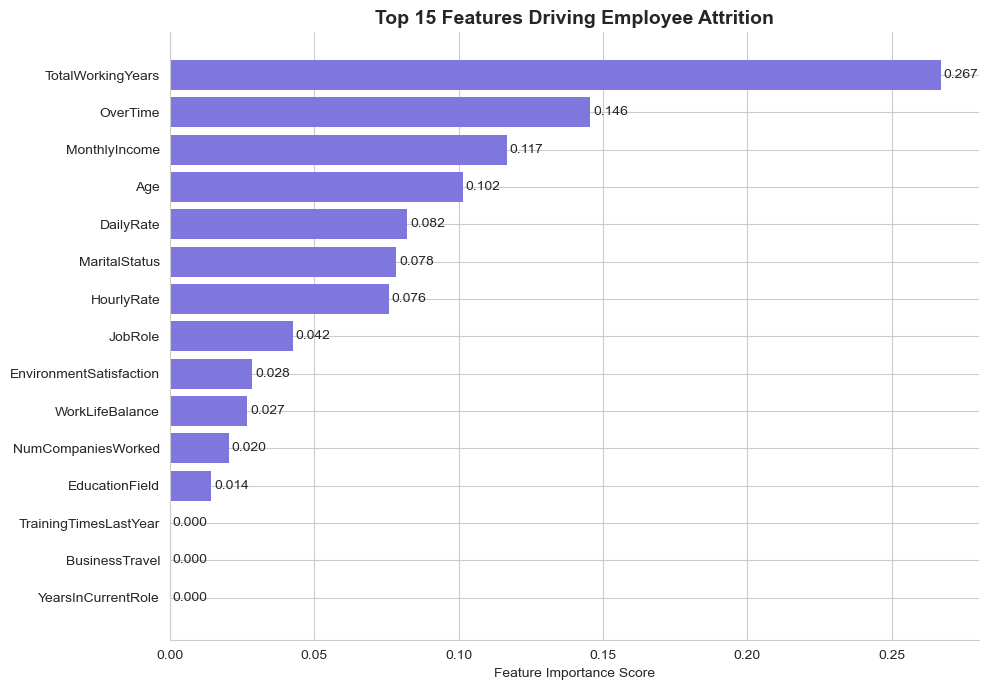

In [13]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importance_df['feature'],
               importance_df['importance'],
               color='#7F77DD', edgecolor='none')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('Top 15 Features Driving Employee Attrition',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()